# Синтетический признак

Синтетический признак - признак или гибрид признаков, образованный путем
конкатенирования двух или более категориальных признаков с целью улавливания взаимодействия между ними. Соединив таким образом два признака, можно закодировать в модель нелинейность, которая обеспечит предсказательные способности, выходящие за рамки того, что каждый из признаков мог бы обеспечить индивидуально.

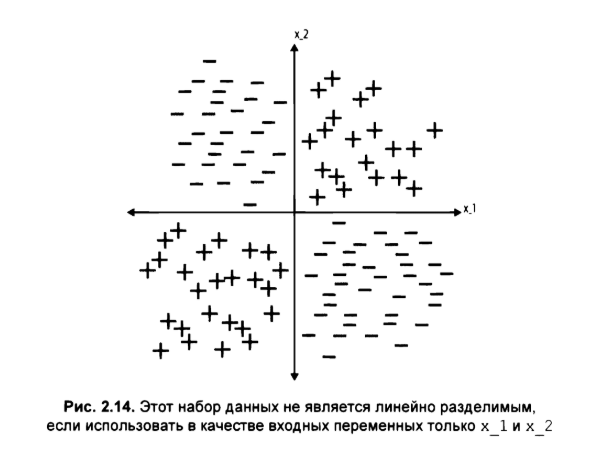

В целях создания признакового столбца для приведенного выше набора данных мы можем сгруппировать $х_1$ и $х_2$ в две корзины в зависимости от их знака. Как следствие, $х_1$ и $х_2$ будут конвертированы в категориальные признаки. Обозначим через А корзину, где $х_1$ >= 0, и через В корзину, где $х_1$ < 0. Обозначим через С корзину, где $х_2$ >= 0, и через D корзину, где $x_2$ < 0 (рис. 2.15).

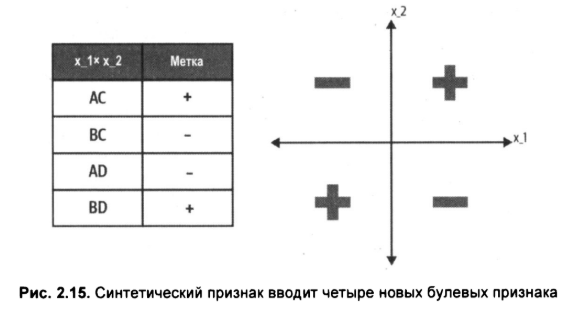

## Ограничения

### 1. Знание предметной области
Знание предметной области играет ключевую роль при выборе эффективных комбинаций признаков для скрещивания. Без понимания природы данных бывает трудно определить, какие взаимодействия признаков действительно окажутся полезными. В таких ситуациях альтернативой может служить использование нейронных сетей, которые способны автоматически выявлять и учитывать значимые комбинации признаков в процессе обучения, но это требует большего объема вычислений.

### 2. Увеличение размерности признакового пространства
После преобразования числовых признаков ($x_1$) и ($x_2$) в категориальные с помощью разбиения на корзины мы получили следующие группы: корзина A, где ($x_1 > 0$), и корзина B, где ($x_1 < 0$); а также корзина C, где ($x_2 > 0$), и корзина D, где ($x_2 < 0$). В таком виде каждый из признаков имеет две категории. Однако их скрещивание приводит к четырём возможным комбинациям (A–C, A–D, B–C, B–D), то есть новый признак имеет уже четыре категории — больше, чем каждый из исходных признаков по отдельности.

Аналогично, если бы вместо двух корзин каждый признак имел 100 категорий для ($x_1$) и 200 категорий для ($x_2$), то их скрещивание создало бы новый признак уже из ($100 \times 200 = 20,000$) категорий, что существенно увеличивает размерность и разреженность конечного признакового пространства.

Рост размерности приводит к тому, что многие категории встречаются редко или не встречаются вовсе, модель получает мало данных для обучения на таких комбинациях, увеличивается риск переобучения, возрастает вычислительная нагрузка, а обобщающая способность модели снижается.


## Библиотеки

In [ ]:
import pandas as pd
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

##Датасет

**NYC Yellow Taxi Trip Data**

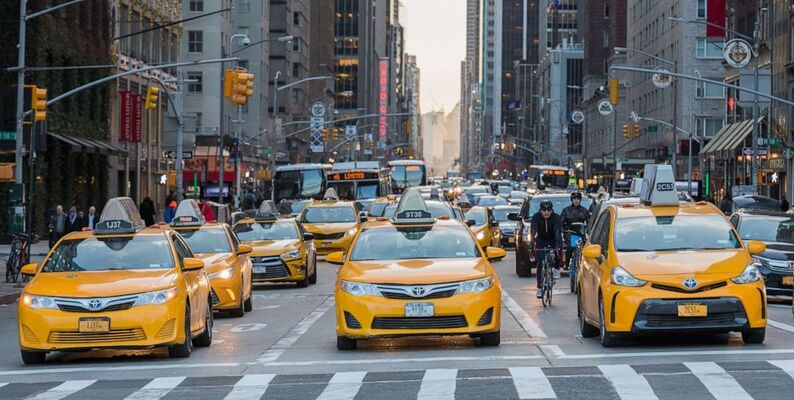

Датасет содержит информацию о поездках жёлтых такси Нью-Йорка за февраль 2016 года. Источником данных является NYC Taxi & Limousine Commission (TLC), которая собирает и публикует данные обо всех поездках своих такси. В данном наборе рассматриваются только поездки жёлтых такси — это классические NYC Yellow Medallion Taxicabs, которые обслуживают пассажиров через обычные уличные вызовы (street hails).

**Основные признаки датасета:**

*VendorID* — код провайдера записи (например, Creative Mobile Technologies, VeriFone Inc.);

*tpep_pickup_datetime* — дата и время начала поездки;

*tpep_dropoff_datetime* — дата и время окончания поездки;

*passenger_count* — количество пассажиров;

*trip_distance* — расстояние поездки в милях;

*pickup_longitude, pickup_latitude* — координаты точки посадки;

*dropoff_longitude, dropoff_latitude* — координаты точки высадки;

*RateCodeID* — код тарифного плана поездки (например, стандартный тариф, JFK, Newark, Nassau/Westchester, групповая поездка и т.д.);

*store_and_fwd_flag* — индикатор "store and forward", показывающий, была ли запись временно сохранена в памяти автомобиля до передачи на сервер (Y — да, N — нет);

*payment_type* — способ оплаты (наличные, карта, без оплаты, спорные/аннулированные поездки);

*fare_amount* — базовая стоимость поездки, рассчитанная по времени и расстоянию;

*extra* — дополнительные сборы (например, ночные и час-пик);

*mta_tax* — налог MTA ($0.50);

*improvement_surcharge* — сбор за улучшение обслуживания ($0.30);

*tip_amount* — чаевые (только по картам, наличные не включены);

*tolls_amount* — сумма уплаченных сборов на платных участках дороги;

*total_amount* — общая сумма поездки, включая все сборы и налоги (кроме наличных чаевых).

**Цель анализа:**

В качестве метки (target) используется *fare_amount* — стоимость поездки. Основная задача — построение модели регрессии для прогнозирования стоимости поездки с использованием доступных признаков и синтетических, а также сравнение результатов.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nyc-yellow-taxi-trip-data' dataset.
Path to dataset files: /kaggle/input/nyc-yellow-taxi-trip-data


In [ ]:
dataset_path = "/kaggle/input/nyc-yellow-taxi-trip-data"

os.listdir(dataset_path)

['yellow_tripdata_2016-01.csv',
 'yellow_tripdata_2016-03.csv',
 'yellow_tripdata_2016-02.csv',
 'yellow_tripdata_2015-01.csv']

In [ ]:
df = pd.read_csv("/kaggle/input/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-02.csv").head(2000000)

df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-02-25 17:24:20,2016-02-25 17:27:20,2,0.70,-73.947250,40.763771,1,N,-73.992012,40.735390,2,5.0,0.0,0.5,0.00,0.0,0.3,5.80
1,2,2016-02-25 23:10:50,2016-02-25 23:31:50,2,5.52,-73.983017,40.750992,1,N,-73.988586,40.758839,2,20.0,0.5,0.5,0.00,0.0,0.3,21.30
2,2,2016-02-01 00:00:01,2016-02-01 00:10:52,6,1.99,-73.992340,40.758202,1,N,-73.964355,40.757977,1,9.5,0.5,0.5,0.70,0.0,0.3,11.50
3,1,2016-02-01 00:00:04,2016-02-01 00:05:16,1,1.50,-73.981453,40.749722,1,N,-73.982323,40.763985,2,6.5,0.5,0.5,0.00,0.0,0.3,7.80
4,2,2016-02-01 00:00:05,2016-02-01 00:20:59,1,5.60,-74.000603,40.729755,1,N,-73.951324,40.669834,1,20.0,0.5,0.5,4.00,0.0,0.3,25.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1,2016-02-05 23:30:54,2016-02-05 23:38:04,1,3.30,-73.988548,40.721451,1,N,-74.012215,40.701622,1,11.5,0.5,0.5,3.20,0.0,0.3,16.00
1999996,2,2016-02-05 23:30:54,2016-02-05 23:47:23,1,3.14,-73.985229,40.758282,1,N,-73.995499,40.723358,2,13.0,0.5,0.5,0.00,0.0,0.3,14.30
1999997,2,2016-02-05 23:30:54,2016-02-05 23:37:29,5,1.46,-73.988449,40.748493,1,N,-73.982765,40.763153,2,7.0,0.5,0.5,0.00,0.0,0.3,8.30
1999998,2,2016-02-05 23:30:54,2016-02-05 23:50:27,5,7.90,-73.964203,40.770458,1,N,-73.989670,40.702419,1,24.5,0.5,0.5,5.16,0.0,0.3,30.96


## Преобразование датасета

In [ ]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.weekday

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [ ]:
df['pickup_weekday'].unique()

array([3, 0, 4, 6, 1, 2], dtype=int32)

0 → Monday (Понедельник)

1 → Tuesday (Вторник)

2 → Wednesday (Среда)

3 → Thursday (Четверг)

4 → Friday (Пятница)

5 → Saturday (Суббота)

6 → Sunday (Воскресенье)

In [ ]:
df['pickup_hour'].unique()

array([17, 23,  0, 20, 16, 21, 22,  8,  9, 13, 10, 11, 12, 14, 15, 18, 19,
        1,  2,  3,  4,  5,  6,  7], dtype=int32)

In [ ]:
cols_to_drop = [
    'total_amount', 'tip_amount', 'tolls_amount', 'extra', 'mta_tax',
    'improvement_surcharge',
    'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag'
]

df = df.drop(columns=cols_to_drop)

In [ ]:
yb = df['fare_amount']
Xb = df.drop(columns=['fare_amount'])

In [ ]:
X_trainb, X_testb, y_trainb, y_testb = train_test_split(Xb, yb, test_size=0.2, random_state=42)

## Обучение модели без синтетичского признака.

In [ ]:
model = LinearRegression()
model.fit(X_trainb, y_trainb)

# Оценка модели
predsb = model.predict(X_testb)

mae = mean_absolute_error(y_testb, predsb)
mse = mean_squared_error(y_testb, predsb)
rmse = mse ** 0.5
r2 = r2_score(y_testb, predsb)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 6.417090732652346
MSE: 109.00425078139102
RMSE: 10.440510082433283
R2: 0.056065648879366714


Качество модели линейной регрессии без синтетического признака является низким. Значение коэффициента детерминации
$𝑅^2  = 0.056$ указывает на то, что модель объясняет лишь около 5.6% вариации целевой переменной. Ошибки MAE и RMSE остаются достаточно высокими, что свидетельствует о слабой предсказательной способности модели и ограниченной пригодности линейной регрессии в текущей постановке задачи.

## Создание синтетического признака “день недели + час”

Создание синтетического признака:

Для улучшения качества модели был создан синтетический признак на основе соединения двух категориальных признаков: дня недели и часа дня.

Логика:

 Cоединение признаков day_of_week × hour_of_day позволяет модели учесть зависимость стоимости поездки от временных паттернов, например, час пик в будние дни отличается от аналогичного часа в выходные.

Техническая реализация:

Каждый возможный вариант дня недели и часа дня представлен как 168-мерный вектор с одним активным состоянием (24 часа × 7 дней = 168). Пример: поездка в понедельник в 17:00 соответствует одному индексу в векторе.

In [ ]:
df['dow_hour'] = df['pickup_weekday'].astype(str) + '_' + df['pickup_hour'].astype(str)

In [ ]:
df = pd.get_dummies(df, columns=['dow_hour', 'RatecodeID', 'payment_type'], drop_first=True)

## Обчение модели с синтетическим признаком

In [ ]:
ys = df['fare_amount']
Xs = df.drop(columns=['fare_amount'])
X_trains, X_tests, y_trains, y_tests = train_test_split(Xs, ys, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_trains, y_trains)

predss = model.predict(X_tests)

mae_1 = mean_absolute_error(y_tests, predss)
mse_1 = mean_squared_error(y_tests, predss)
rmse_1 = mse_1 ** 0.5
r2_1 = r2_score(y_tests, predss)

print('MAE:', mae_1)
print('MSE:', mse_1)
print('RMSE:', rmse_1)
print('R2:', r2_1)

MAE: 5.433520751713284
MSE: 74.64723603971936
RMSE: 8.63986319565995
R2: 0.35358401338482126


In [ ]:
data = {
    "model": ["LinearRegression", "LinearRegression (with synt data)"],
    "MAE": [mae, mae_1],
    "MSE": [mse, mse_1],
    "R2": [r2, r2_1],
    "RMSE": [rmse, rmse_1]
}

df_metrics = pd.DataFrame(data, index=["Базовый набор атрибутов", "С синтетическим признаком"])

df_metrics

,model,MAE,MSE,R2,RMSE
Базовый набор атрибутов,LinearRegression,6.417091,109.004251,0.056066,10.440510
С синтетическим признаком,LinearRegression (with synt data),5.433521,74.647236,0.353584,8.639863


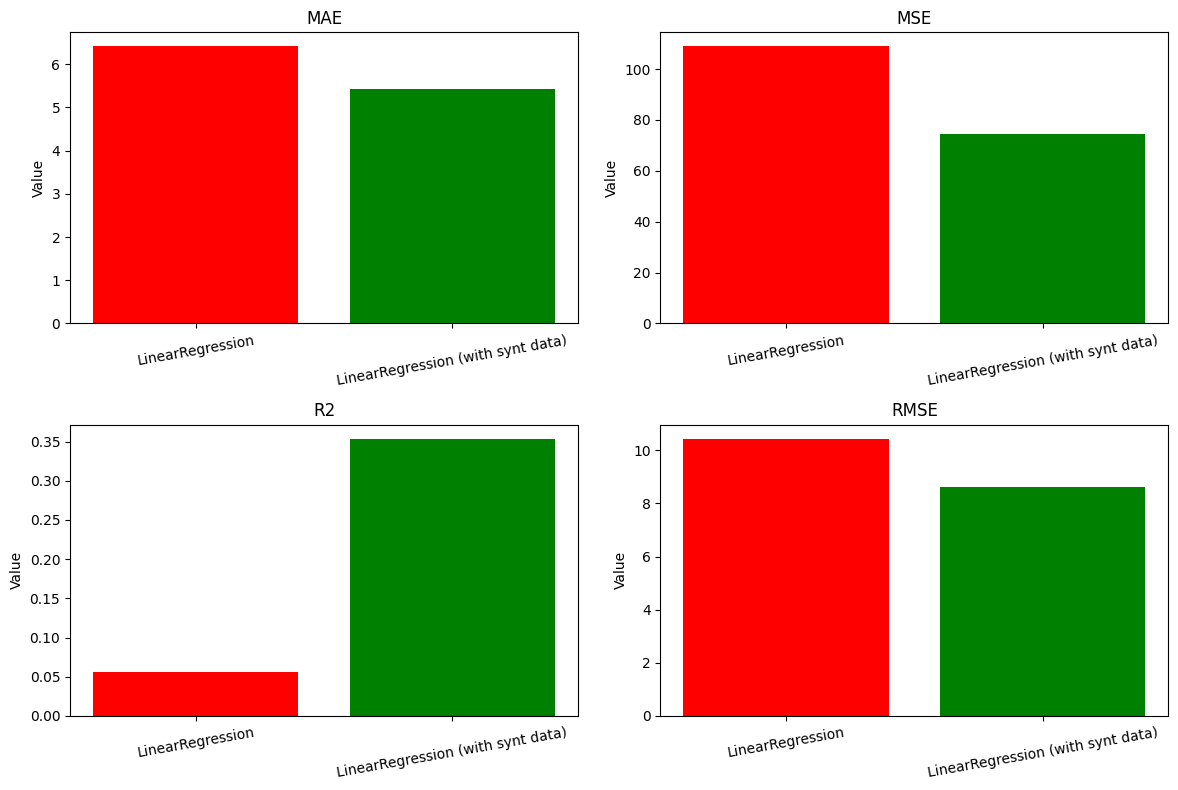

In [ ]:
metrics = ["MAE", "MSE", "R2", "RMSE"]
colors = ["red", "green"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
x = range(len(df_metrics["model"]))

for metric, pos in zip(metrics, positions):
    ax = axes[pos]
    ax.bar(x, df_metrics[metric], color = colors)
    ax.set_title(metric)
    ax.set_ylabel("Value")
    ax.set_xticks(x)
    ax.set_xticklabels(df_metrics["model"], rotation=10)

plt.tight_layout()
plt.show()

Добавление синтетического признака привело к заметному улучшению качества модели линейной регрессии. Во всех ключевых метриках наблюдаются положительные изменения. Таким образом, синтетический признак внёс дополнительную информацию, которую модель не могла извлечь из исходного набора атрибутов. Это позволило улучшить способность модели к обобщению и сделать её предсказания более точными.

## Анализ важности признаков после добавления синтетического признака

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_trains)
X_test_scaled = scaler.transform(X_tests)

model = LinearRegression()
model.fit(X_train_scaled, y_trains)

LinearRegression()

In [ ]:
importance = pd.Series(
    abs(model.coef_),
    index=X_trains.columns
).sort_values(ascending=False)

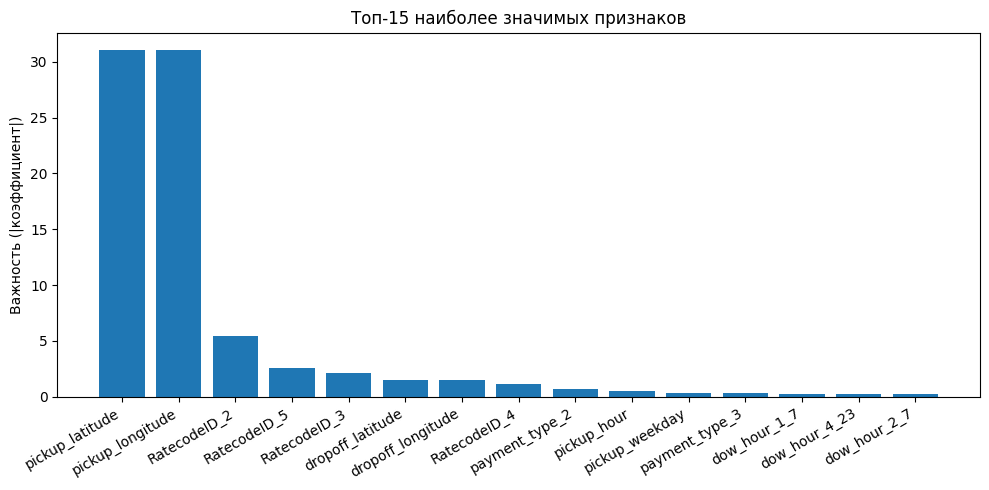

In [ ]:
top_k = 15

top_features = importance.head(top_k)

plt.figure(figsize=(10, 5))
plt.bar(top_features.index, top_features.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Важность (|коэффициент|)")
plt.title(f"Топ-{top_k} наиболее значимых признаков")
plt.tight_layout()
plt.show()

По результатам анализа видно, что наибольшее влияние на модель оказывают пространственные признаки pickup_latitude и pickup_longitude, которые существенно превосходят остальные признаки по величине коэффициентов. Это указывает на доминирующую роль географического положения в формировании предсказаний модели.

Синтетические признаки dow_hour_*, отражающие совместное влияние дня недели и часа, присутствуют среди наиболее значимых, однако их коэффициенты заметно меньше по сравнению с ведущими признаками. Это означает, что синтетический признак не является ключевым фактором, но при этом вносит дополнительную информацию в модель.

Таким образом, синтетический признак оказывает умеренное влияние на структуру модели: он не определяет предсказание в одиночку, но дополняет основные признаки и может рассматриваться как вспомогательный фактор.

# Источники

Lakshmanan V., Robinson S., Mipp M. Machine Learning Design Patterns: Solutions to Common Challenges in Data Preparation, Model Building, and MLOps. — O'Reilly Media, 2022. — 432 p.

Zheng A., Casari A. Feature Engineering for Machine Learning: Principles and Techniques for Data Scientists. — O'Reilly Media, 2018. — 352 p.

Категориальные данные: перекрестия признаков [Электронный ресурс]. — Режим доступа: https://developers.google.com/machine-learning/crash-course/categorical-data/feature-crosses?hl=ru
 — Дата обращения: 19.11.2025.

FeatureTools [Электронный ресурс]. — Режим доступа: https://featuretools.alteryx.com/
 — Дата обращения: 19.11.2025.

NYC Yellow Taxi Trip Data [Электронный ресурс]. — Kaggle. — Режим доступа: https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data
 — Дата обращения: 19.11.2025.